In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



In [20]:
data = pd.read_csv('/content/Loan Approval dataset.zip')
df = pd.DataFrame(data)
df.columns = df.columns.str.strip()
df.ffill(inplace=True)

In [21]:
le = LabelEncoder()
# Corrected categorical columns based on the actual DataFrame
cat_cols = ['education', 'self_employed', 'loan_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [22]:
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

/tmp/ipykernel_5305/2064825778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='income_annum', data=df, palette='Set2')


([<matplotlib.axis.XTick at 0x7cc31dbdd670>,
 [Text(0, 0, 'Rejected'), Text(1, 0, 'Approved')])

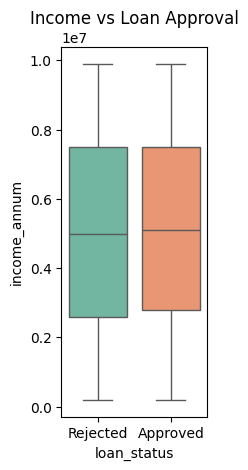

In [23]:
plt.subplot(1, 3, 1)
sns.boxplot(x='loan_status', y='income_annum', data=df, palette='Set2')
plt.title('Income vs Loan Approval')
plt.xticks([0, 1], ['Rejected', 'Approved'])


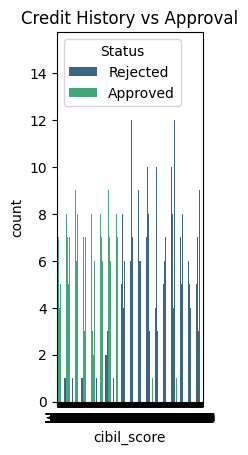

In [24]:
plt.subplot(1, 3, 2)
sns.countplot(x='cibil_score', hue='loan_status', data=df, palette='viridis')
plt.title('Credit History vs Approval')
plt.legend(title='Status', labels=['Rejected', 'Approved'])


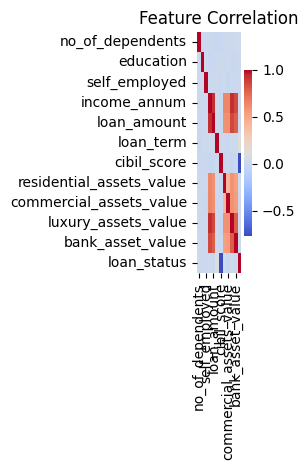

In [25]:
plt.subplot(1, 3, 3)
sns.heatmap(df.drop('loan_id', axis=1).corr(), annot=False, cmap='coolwarm') # Fix applied here
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

In [26]:
X = df[['income_annum', 'loan_amount', 'cibil_score', 'education']]
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [28]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

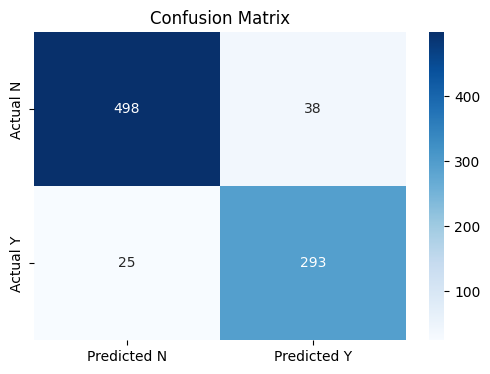

In [29]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'])
plt.title('Confusion Matrix')
plt.show()

In [30]:
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Performance ---
Accuracy Score: 92.62%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       536
           1       0.89      0.92      0.90       318

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854

